#Import Required Libraries

---




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# For clean display
sns.set(style="whitegrid")

# Load Dataset


In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Data Inspection

In [ ]:
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive stats:")
display(df.describe(include='all'))


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive stats:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


# Gender Distribution


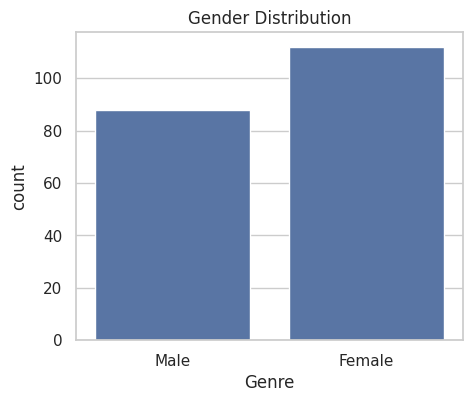

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution


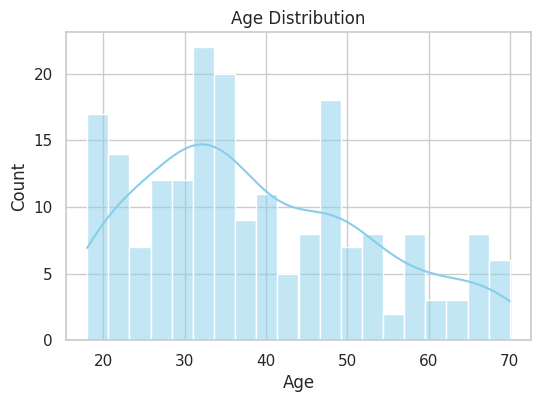

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

# Annual Income Distribution


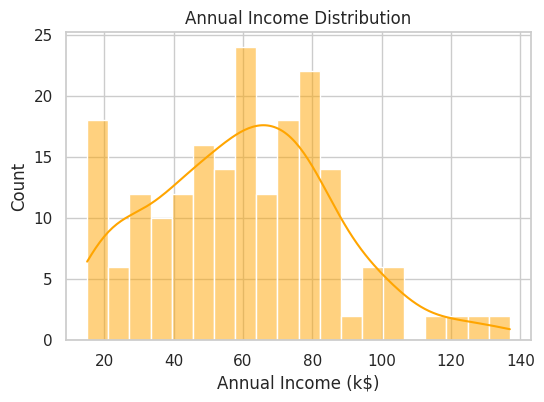

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='orange')
plt.title("Annual Income Distribution")
plt.show()

# Income vs Spending (Gender hue)


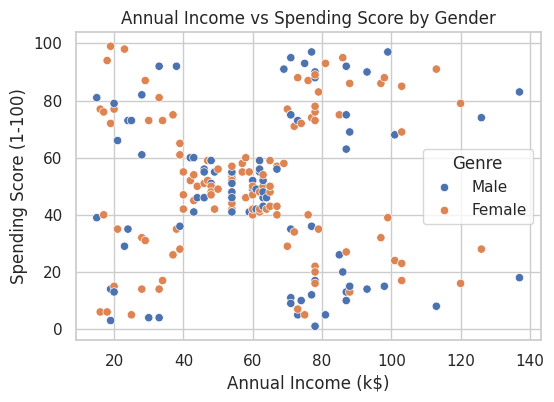

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df)
plt.title("Annual Income vs Spending Score by Gender")
plt.show()

#Data Preprocessing


In [ ]:
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])  # Female=0, Male=1

In [ ]:
# Select relevant features
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#K-Means Clustering


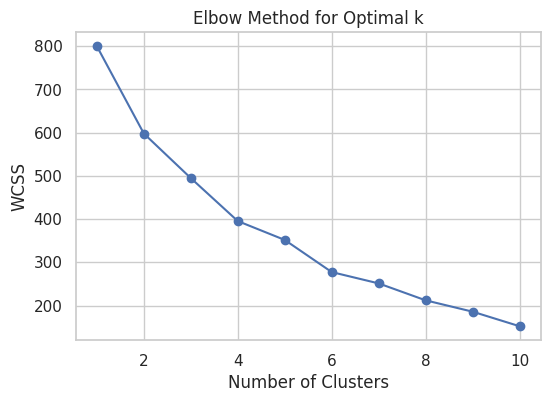

In [ ]:
# Find optimal number of clusters (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, 'bo-')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Choose k=5 (based on elbow point)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

#Cluster Summary


In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\n--- Cluster Summary ---")
print(cluster_summary)


--- Cluster Summary ---
         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         65.333333  0.509804  56.470588           46.098039   
1        159.500000  1.000000  39.500000           85.150000   
2        100.809524  1.000000  28.690476           60.904762   
3        151.510204  0.000000  37.897959           82.122449   
4         50.526316  0.000000  27.315789           38.842105   

         Spending Score (1-100)  
Cluster                          
0                     39.313725  
1                     14.050000  
2                     70.238095  
3                     54.448980  
4                     56.210526  


# Visualize clusters by Income & Spending


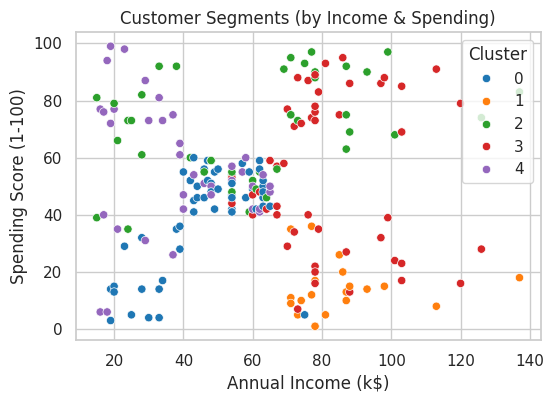

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='tab10')
plt.title("Customer Segments (by Income & Spending)")
plt.show()

#PCA Visualization


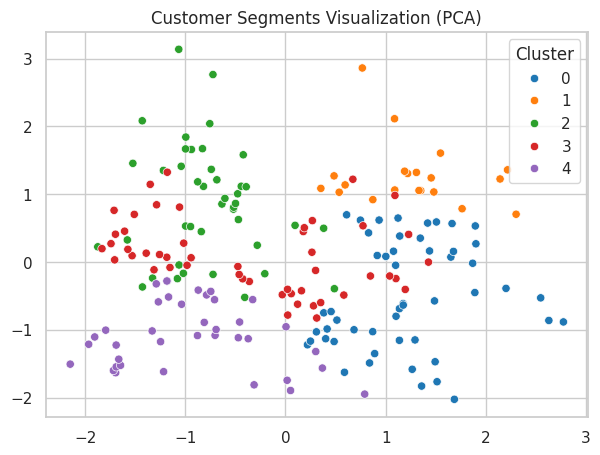

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['Cluster'], palette='tab10')
plt.title("Customer Segments Visualization (PCA)")
plt.show()

#Marketing Insights


In [ ]:
print("\n💡 Marketing Strategy Suggestions:")

strategies = {
    0: "Cluster 0: High Income & High Spending — Target for premium products and VIP offers.",
    1: "Cluster 1: Low Income & Low Spending — Focus on budget deals and discounts.",
    2: "Cluster 2: Young & High Spending — Trend-based marketing and social media campaigns.",
    3: "Cluster 3: High Income but Low Spending — Introduce loyalty programs and incentives.",
    4: "Cluster 4: Average Income & Moderate Spending — Use regular seasonal sales."
}

for key, value in strategies.items():
    print(value)



💡 Marketing Strategy Suggestions:
Cluster 0: High Income & High Spending — Target for premium products and VIP offers.
Cluster 1: Low Income & Low Spending — Focus on budget deals and discounts.
Cluster 2: Young & High Spending — Trend-based marketing and social media campaigns.
Cluster 3: High Income but Low Spending — Introduce loyalty programs and incentives.
Cluster 4: Average Income & Moderate Spending — Use regular seasonal sales.
